In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
class Value:

    def __init__(self, data, _children=(), _op="", label=""):
        self.data = data
        self.grad = 0.0  # gradient
        # 0 means no effect
        # representing the derivative of the output
        self._backward = lambda: None  # there's nothing to do in the leaf node

        self._prev = set(_children)  # just for efficiecy
        self._op = _op  # operator
        self.label = label

    def __repr__(self):  # representation on jupyter notebook
        return f"Value(data={self.data})"

    def __add__(self, other):  # addition
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")  # new Value object

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad

        out._backward = _backward

        return out

    def __radd__(self, other):  # other + self
        return self + other

    def __mul__(self, other):  # multiplication
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")  # new Value object

        # switch gate
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward

        return out

    def __pow__(self, other):
        assert isinstance(
            other, (int, float)
        ), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f"**{other}")

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad

        out._backward = _backward

        return out

    def __rmul__(self, other):  # other * self
        return self * other

    def __truediv__(self, other):  # self / other
        return self * other**-1

    def __neg__(self):  # -self
        return self * -1

    def __sub__(self, other):  # self - other
        return self + (-other)

    def tanh(self):
        x = self.data
        t = (math.exp(2 * x) - 1) / (math.exp(2 * x) + 1)
        out = Value(t, (self,), "tanh")

        def _backward():
            self.grad += (1 - t**2) * out.grad

        out._backward = _backward

        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), "exp")

        def _backward():
            self.grad += out.data * out.grad

        out._backward = _backward

        return out

    def backward(self):
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [3]:
from graphviz import Digraph


def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format="svg", graph_attr={"rankdir": "LR"})  # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(
            name=uid,
            label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad),
            shape="record",
        )
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [4]:
# inputs x1,x2
# refers to synaptic strength
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")
# weights w1, w2
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")
# bias of the neuron
b = Value(6.88137, label="b")

# x1*w1 + x2*w2 + b
x1w1 = x1 * w1
x1w1.label = "x1*w1"

x2w2 = x2 * w2
x2w2.label = "x2*w2"

x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = "x1*w1 + x2*w2"

n = x1w1x2w2 + b
n.label = "n"

e = (2 * n).exp()
o = (e - 1) / (e + 1)
o.label = "o"

o.backward()

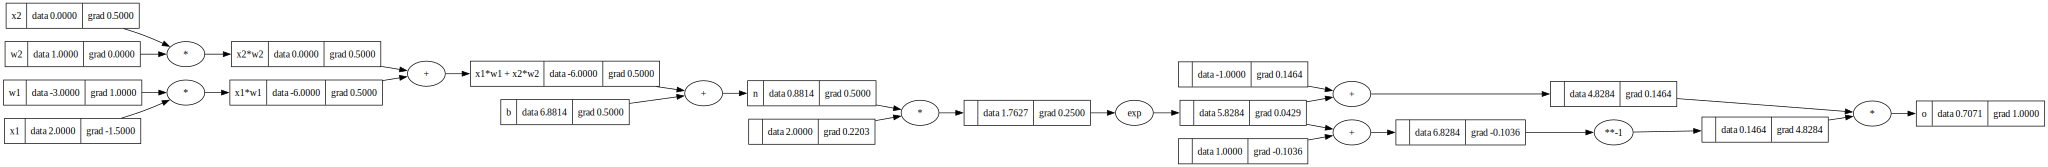

In [5]:
draw_dot(o)

In [6]:
a = Value(2.0)
a + 1

Value(data=3.0)

In [7]:
a * 2

Value(data=4.0)

In [8]:
b = Value(4.0)
a / b

Value(data=0.5)

In [9]:
a - b

Value(data=-2.0)

In [10]:
import torch

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.5.1


In [11]:
torch.Tensor([[1, 2, 3], [4, 5, 6]])
"""
tensor([[1., 2., 3.],
        [4., 5., 6.]])
"""

'\ntensor([[1., 2., 3.],\n        [4., 5., 6.]])\n'

In [12]:
torch.Tensor([[1, 2, 3], [4, 5, 6]]).shape
"""
torch.Size([2, 3])
"""

'\ntorch.Size([2, 3])\n'

In [13]:
torch.Tensor([[1, 2, 3], [4, 5, 6]]).dtype
"""
torch.float32
"""

'\ntorch.float32\n'

In [14]:
torch.Tensor([2.0]).double().dtype
"""
torch.float64
"""

'\ntorch.float64\n'

In [15]:
x1 = torch.Tensor([2.0]).double()
x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()
x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()
w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()
w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()
b.requires_grad = True
n = x1 * w1 + x2 * w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print("---")
print("x2", x2.grad.item())
print("w2", w2.grad.item())
print("x1", x1.grad.item())
print("w1", w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [16]:
o.item()  # 0.7071066904050358
o.data.item()  # 0.7071066904050358

0.7071066904050358

In [17]:
x2.grad.item()  # 0.5000001283844369

0.5000001283844369

In [18]:
import random


class Neuron:
    def __init__(self, nin):  # nin: number of inputs
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]  # weight
        self.b = Value(random.uniform(-1, 1))  # bias

    def __call__(self, x):
        # w * x + b
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]


class Layer:

    def __init__(self, nin, nout):  # nout: number of outs
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
        params = []
        for neuron in self.neurons:
            ps = neuron.parameters()
            params.extend(ps)
        return params


class MLP:  # Multi layer perceptron
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i + 1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [19]:
x = [2.0, 3.0, -1.0]  # 3 inputs
n = MLP(3, [4, 4, 1])  # into 2-layers of four and one ouput
n(x)

Value(data=0.40696385009093544)

In [20]:
xs = [[2.0, 3.0, -1.0], [3.0, -1.0, 0.5], [0.5, 1.0, 1.0], [1.0, 1.0, -1.0]]
ys = [1.0, -1.0, -1.0, 1.0]  # desired targets

In [71]:
for k in range(20000):
    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt) ** 2 for ygt, yout in zip(ys, ypred))

    # backward pass

    for p in n.parameters():
        p.grad = 0.0
    loss.backward()

    # update
    for p in n.parameters():
        p.data += -0.05 * p.grad

    print(k, loss.data)

0 3.8167629779375955e-06
1 3.816587424253105e-06
2 3.816411886359659e-06
3 3.816236364254607e-06
4 3.816060857935912e-06
5 3.815885367401536e-06
6 3.815709892649441e-06
7 3.815534433677283e-06
8 3.815358990483335e-06
9 3.815183563064945e-06
10 3.815008151420074e-06
11 3.814832755547301e-06
12 3.8146573754433643e-06
13 3.814482011107145e-06
14 3.814306662536304e-06
15 3.814131329728189e-06
16 3.813956012681074e-06
17 3.8137807113929215e-06
18 3.8136054258610843e-06
19 3.813430156084139e-06
20 3.8132549020594385e-06
21 3.8130796637852563e-06
22 3.8129044412592487e-06
23 3.8127292344793824e-06
24 3.812554043443319e-06
25 3.8123788681493274e-06
26 3.8122037085950678e-06
27 3.8120285647785088e-06
28 3.8118534366973092e-06
29 3.811678324349129e-06
30 3.8115032277325486e-06
31 3.811328146845227e-06
32 3.8111530816848274e-06
33 3.8109780322490077e-06
34 3.8108029985363515e-06
35 3.8106279805442126e-06
36 3.8104529782708647e-06
37 3.8102779917139692e-06
38 3.810103020871189e-06
39 3.80992806574